# OHLC Trading Signals: Why Naive CV Lies About Your Edge

Real daily BTC/USDT candles, fetched with `pricehub`. This is the case the library was built for. You have OHLC bars. You build a feature, label each bar by the return over the next `H` bars, and cross-validate to check whether the feature predicts that return.

Two things make it leak. First: the forward-return label of bar `t` overlaps the labels of its neighbours. They share `H - 1` of the same future bars, so adjacent labels are almost the same number. Second: cumulative traded volume is a feature people actually use, and it only ever goes up. That makes it an accidental clock.

Crypto returns have no easy edge for a volume feature. So a large cross-validated score is not skill. It is leakage. This notebook is a real-data demonstration. The controlled proof lives in `synthetic_leakage_proof.ipynb`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from pricehub import get_ohlc
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor

from purgedcv import PurgedKFold
from purgedcv.diagnostics import compute_overlap_fraction

INTERVAL = "1d"  # any pricehub interval; bar duration is inferred from data
SEED = 0
H = 20  # label = return over the next H trading days
N_SPLITS = 5

## Fetch and cache the candles

`pricehub` pulls Binance spot BTC/USDT daily bars. The window is pinned to 2021-01-01 through 2023-09-28, so the result is reproducible. The frame is cached to CSV in `examples/data/` (git-ignored). Later runs are offline. The data is public; the exchange's API terms apply. Change `INTERVAL` to pull any timeframe.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / f"btcusdt_{INTERVAL}_binance_spot_2021_2023.csv"

if cache.exists():
    print(f"Using cached: {cache}")
    raw = pd.read_csv(cache, index_col=0, parse_dates=True)
else:
    print("Fetching via pricehub (binance_spot, BTCUSDT, 1d) ...")
    raw = get_ohlc(
        broker="binance_spot",
        symbol="BTCUSDT",
        interval=INTERVAL,
        start="2021-01-01",
        end="2023-09-28",
    )
    raw.to_csv(cache)

ohlc = raw[["Open", "High", "Low", "Close", "Volume"]].rename(
    columns={"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume"}
)
ohlc.index = pd.to_datetime(ohlc.index)
BAR = ohlc.index.to_series().diff().median()  # one bar's duration
print(f"{len(ohlc)} daily bars, {ohlc.index[0].date()} to {ohlc.index[-1].date()}")
ohlc.head()

Using cached: data/btcusdt_1d_binance_spot_2021_2023.csv
1001 daily bars, 2021-01-01 to 2023-09-28


,open,high,low,close,volume
Open time,,,,,
2021-01-01,28923.63,29600.00,28624.57,29331.69,54182.925011
2021-01-02,29331.70,33300.00,28946.53,32178.33,129993.873362
2021-01-03,32176.45,34778.11,31962.99,33000.05,120957.566750
2021-01-04,33000.05,33600.00,28130.00,31988.71,140899.885690
2021-01-05,31989.75,34360.00,29900.00,33949.53,116049.997038


## Feature and forward-return label

The feature is cumulative volume. It is real, widely used, and monotone in time. The label is the log return over the next `H` bars, so neighbouring labels overlap heavily.

In [3]:
feature = ohlc["volume"].cumsum().to_numpy().reshape(-1, 1)
log_close = np.log(ohlc["close"].to_numpy())
n = len(ohlc) - H
y = log_close[H : H + n] - log_close[:n]  # return over the next H bars
features = feature[:n]

pred = pd.Series(ohlc.index.to_numpy()[:n])
evalu = pred + H * BAR

corr = np.corrcoef(features.ravel(), y)[0, 1]
print(
    f"corr(cumulative volume, forward return) = {corr:+.3f}  "
    "(no economic reason for skill; a large CV score here is leakage)"
)

corr(cumulative volume, forward return) = +0.055  (no economic reason for skill; a large CV score here is leakage)


## Naive shuffled k-fold vs PurgedKFold

Shuffle the bars into folds and each bar's near-duplicate neighbours scatter into training. `PurgedKFold` removes the training bars whose forward-return window overlaps the test window. That is the whole difference.

In [4]:
naive = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
purged = PurgedKFold(
    n_splits=N_SPLITS,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=H * BAR,
    embargo=H * BAR,
)
model = KNeighborsRegressor(n_neighbors=10)

naive_r2 = float(cross_val_score(model, features, y, cv=naive, scoring="r2").mean())
purged_r2 = float(cross_val_score(model, features, y, cv=purged, scoring="r2").mean())


def mean_overlap(cv):
    fr = [compute_overlap_fraction(tr, te, pred, evalu) for tr, te in cv.split(features, y)]
    return float(np.mean(fr))


print(f"naive shuffled KFold R^2 : {naive_r2:+.3f}")
print(f"PurgedKFold R^2          : {purged_r2:+.3f}")
print()
print(f"label overlap, naive  : {mean_overlap(naive):.1%} of training bars leak")
print(f"label overlap, purged : {mean_overlap(purged):.1%} of training bars leak")

naive shuffled KFold R^2 : +0.855
PurgedKFold R^2          : -1.211

label overlap, naive  : 100.0% of training bars leak
label overlap, purged : 0.0% of training bars leak


## The price path and the verdict

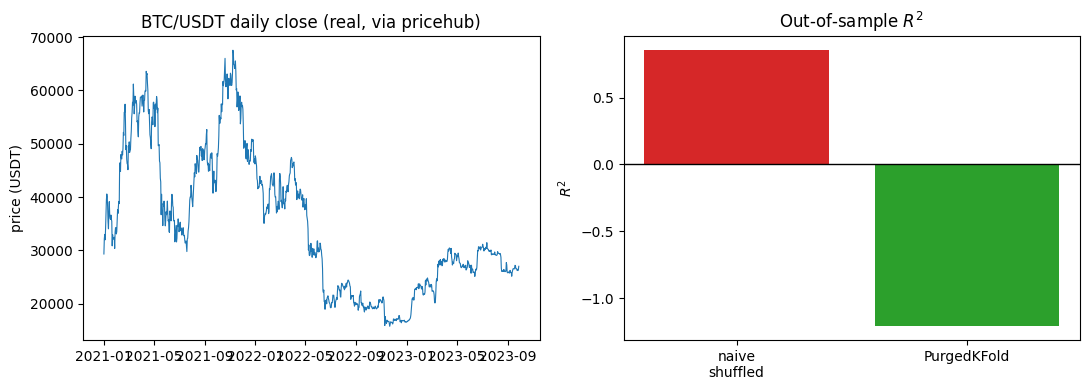

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(ohlc.index, ohlc["close"], color="#1f77b4", linewidth=0.8)
ax1.set_title("BTC/USDT daily close (real, via pricehub)")
ax1.set_ylabel("price (USDT)")

ax2.bar(["naive\nshuffled", "PurgedKFold"], [naive_r2, purged_r2], color=["#d62728", "#2ca02c"])
ax2.axhline(0.0, color="black", linewidth=1)
ax2.set_title("Out-of-sample $R^2$")
ax2.set_ylabel("$R^2$")
plt.tight_layout()
plt.show()

## Verdict

Naive shuffled k-fold reports a clearly positive R² for a cumulative-volume feature that has no economic reason to forecast returns. The cause is mechanical. Every training bar's forward-return label overlaps the test bars next to it. `PurgedKFold` cuts that overlap to zero and the apparent edge collapses.

This is the trap behind backtests that look great and lose money live. The library does not find an edge. It stops a non-edge from looking like one.

**Data:** Binance spot BTC/USDT 1-day candles via the `pricehub` package, pinned window 2021-01-01 to 2023-09-28. Public market data; the exchange's API terms apply.